# Bootstraping de estructura genética poblacional en *Callisaurus draconoides*

## Introducción

### Descripción del problema

En este trabajo se analizan secuencias genéticas de individuos de la especie *Callisaurus draconoides* con el objetivo de evaluar si existe evidencia estadística compatible con la presencia de múltiples grupos genéticamente diferenciados en una población.

El conjunto de datos consiste en secuencias de nucleótidos correspondientes a dos marcadores genéticos independientes: `mc1r` y `cybt`.

Cada marcador fue transformado en una matriz numérica de tipo: 

$$
\text{individuos}\times \text{secuencia de nucleotidos}
$$

donde: 

* cada fila reprecenta un individuo,
* cada columna reprecenta la posición de un nucleótido,
* y los valores corresponden a codificaciones numéricas de nucleótidos.

---

### Hipótesis

Se plantea el siguiente problema de inferencia: 

$$
H_0: ~\text{Todos los individuos pertenecen a una misma subespecie}
$$

$$
H_1: ~\text{Existen almenos dos grupos geneticamente diferenciados}
$$

---

### Metodología general

El análisis se basa en técnicas de: 

* distancia genética,
* reducción de dimensionalidad
* clustering jerárquico
* y bootstrap.

La metodologia princiapl consiste en: 
1. calcular distancias genéticas entre individuos,
2. construir agrupamientos jerárquicos,
3. y evaluar la estabilidad de clusters mediante bootstrap.

---

## Setup

In [1]:
from pathlib import Path

In [2]:
# basics
import numpy as np
import pandas as pd

In [3]:
# sklearn
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

In [4]:
# clustering-scipy
from scipy.cluster.hierarchy import (
    linkage, 
    dendrogram, 
    fcluster
)
from scipy.spatial.distance import squareform

In [5]:
# viz
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

In [6]:
# utils
from tqdm import tqdm
from IPython.display import HTML, display

In [7]:
# plot configs
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [8]:
# paths
data_dir = Path("../data")
processed_data_dir = data_dir / "processed"

mc1r_path = processed_data_dir / "mc1r_encoded.csv"
cybt_path = processed_data_dir / "cytb_encoded.csv"

assert mc1r_path.is_file() and cybt_path.is_file(), "El archivo no existe, ejecuta la libreta `nbs/data.ipynb`"

results_dir = Path("../results")
results_bootstrap_dir = results_dir / "bootstrap"
results_bootstrap_dir.mkdir(exist_ok=True)

---

## Datos

Cada dataset reprecenta una matriz genética de tipo: 

$$
\text{individuo}\times\text{secuencia de nucleotidos}
$$
donde: 
* cada fila corresponde a un individuo,
* cada columna corresponde a una posición nucleórica,
* y cada valore reprecenta una codificación numérica de nucleótidos.

Los datasets corresponden con los dos marcadores genéticos: `cybt`, `mc1r`. 

El análisis separado de ambos marcadores permitirá comparar la estabilidad y consisrtencia de la estructura genética observada.

Cargamos los datasets: 

In [9]:
cybt_df = pd.read_csv(cybt_path)
cybt_df.head()

,id,0,1,2,3,4,5,6,7,8,...,1017,1018,1019,1020,1021,1022,1023,1024,1025,1026
0,KR026343,2,1,1,3,0,0,3,3,0,...,2,0,3,0,0,0,0,3,3,3
1,KR026344,2,1,1,3,0,0,3,3,0,...,2,0,3,0,0,0,0,3,3,3
2,KR026345,2,1,1,3,0,0,3,3,0,...,2,0,3,0,0,0,0,3,3,3
3,KR026346,2,1,1,3,0,0,3,3,0,...,2,0,3,0,0,0,0,3,3,3
4,KR026347,2,1,1,3,0,0,3,3,0,...,2,0,3,0,0,0,0,3,3,3


In [10]:
mc1r_df = pd.read_csv(mc1r_path)
mc1r_df.head()

,id,0,1,2,3,4,5,6,7,8,...,805,806,807,808,809,810,811,812,813,814
0,KR026455,1,2,2,0,2,3,3,2,1,...,2,3,1,0,1,3,2,2,1,0
1,KR026456,1,2,2,0,2,3,3,2,1,...,2,3,1,2,1,3,2,2,1,0
2,KR026457,1,2,2,0,2,3,3,2,1,...,2,3,1,2,1,3,2,2,1,0
3,KR026458,1,2,2,0,2,3,3,2,1,...,2,3,1,2,1,3,2,2,1,0
4,KR026459,1,2,2,0,2,3,3,2,1,...,2,3,1,2,1,3,2,2,1,0


Definimos un dataframe auxiliar para separar los ID's y los valores de cada cadena. 

Los ID's: 

In [11]:
cybt_id = cybt_df['id']
mc1r_id = mc1r_df['id']

Los valores:

In [12]:
X_cybt = cybt_df.drop('id', axis=1).values
X_mc1r = mc1r_df.drop('id', axis=1).values

---

## Distancia genética

Para cuantificar la similitud genética entre individuos utilizaremos la [distancia de Hamming](https://en.wikipedia.org/wiki/Hamming_code).

La distancia de Hamming mide la proporción de posiciones nucleoticas diferentes entre dos secuencias de [ADN](https://www.datacamp.com/tutorial/hamming-distance). 

Se define como: 

$$
d(x, y) = \frac{1}{p} \sum_{i=1}^{p}\mathbb{I}(x_i\neq y_i)
$$

donde: 

* $p$ reprecenta el número total de posiciones nucleóticas (longitud de la cadena),
* y $\mathbb{I}$ es una función indicadora de diferencia.

Esta métrica es adecuada en este contexto debido  que: 

* las secuencias de un mismo indicador poseen la misma longitud,
* los datos son categóricos discretos,
* y el objetivo principal es medir las diferencias por posición nucleótica.

La distancia de Hamming la podemos computar usando la función de `pairwise_distances` (de `sklearn.metrics`). 

In [13]:
# genetic distnaces
D_cybt = pairwise_distances(
    X_cybt, 
    metric='hamming'
)

D_mc1r = pairwise_distances(
    X_mc1r, 
    metric='hamming'
)

## PCA

A continuación, exploramos la técnica de reducción de dimensionalidad via PCA (*Principal Component Analysis)*.

El objetivo es proyectar los individuos en un espacio de menor dimensión preservando la variabilidad en los datos originales.

La visualización de los dos primeros compenentes principales permite explorar evidencia de agrupamientos poblacionales.

In [14]:
pca = PCA(n_components=2)

X_pca_cybt = pca.fit_transform(X_cybt)
X_pca_mc1r = pca.fit_transform(X_mc1r)

Graficamos los resultados: 

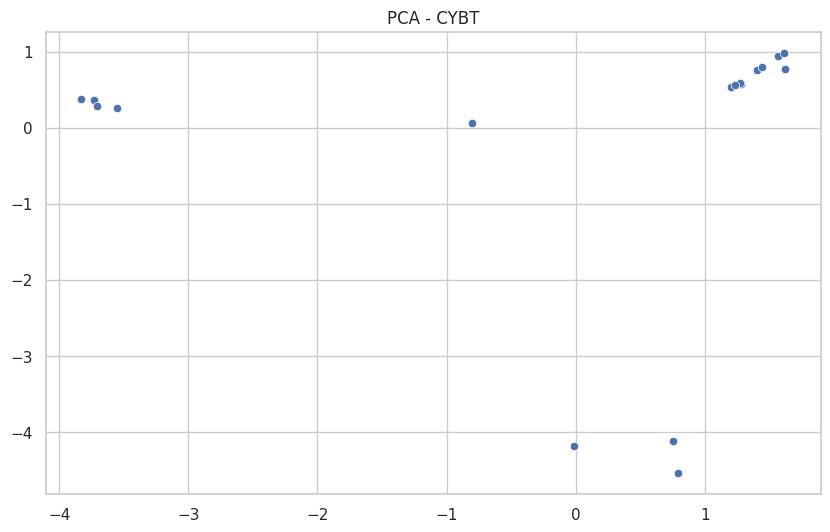

In [15]:
fig, ax = plt.subplots()

sns.scatterplot(
    x=X_pca_cybt[:, 0],
    y=X_pca_cybt[:, 1], 
    ax=ax
)

ax.set_title('PCA - CYBT')

plt.savefig(results_bootstrap_dir / "pca_cybt.png")
plt.show()

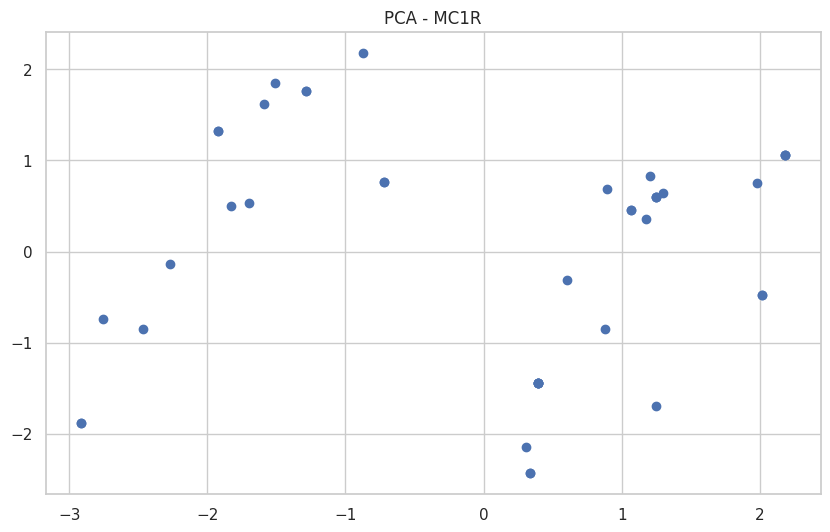

In [16]:
fig, ax = plt.subplots()

ax.scatter(
    X_pca_mc1r[:, 0],
    X_pca_mc1r[:, 1]
)

ax.set_title('PCA - MC1R')

plt.savefig(results_bootstrap_dir / "pca_mc1r.png")
plt.show()

---

## Cluestering jerárquico

A continuación realizamos clustering jerárquico para identificar posibles agrupamientos genéticos entre individuos. 

El método permite construir un dentrograma a martir de la matriz de distancias genéticas, fusionando iterativamente los grupos similares.

El objetivo es evaluar si existen estructuras de agrupamiento consistentes compatibles con multiples subpoblaciones. 

In [17]:
# hierearchical clustering

Z_cybt = linkage(
    squareform(D_cybt),
    method='average'
)

labels_cybt = fcluster(
    Z_cybt, 
    t=4, 
    criterion='maxclust'
)

score_cybt = silhouette_score(
    D_cybt, 
    labels_cybt, 
    metric='precomputed'
)

Z_mc1r = linkage(
    squareform(D_mc1r),
    method='average'
)

labels_mc1r = fcluster(
    Z_mc1r, 
    t=2, 
    criterion='maxclust'
)

score_mc1r = silhouette_score(
    D_mc1r, 
    labels_mc1r, 
    metric='precomputed'
)

In [18]:
print('cybt - silhouette score', score_cybt)
print('mc1r - silhouette score', score_mc1r)

cybt - silhouette score 0.7374315575041016
mc1r - silhouette score 0.32214123594503025


Graficamos los resultados:

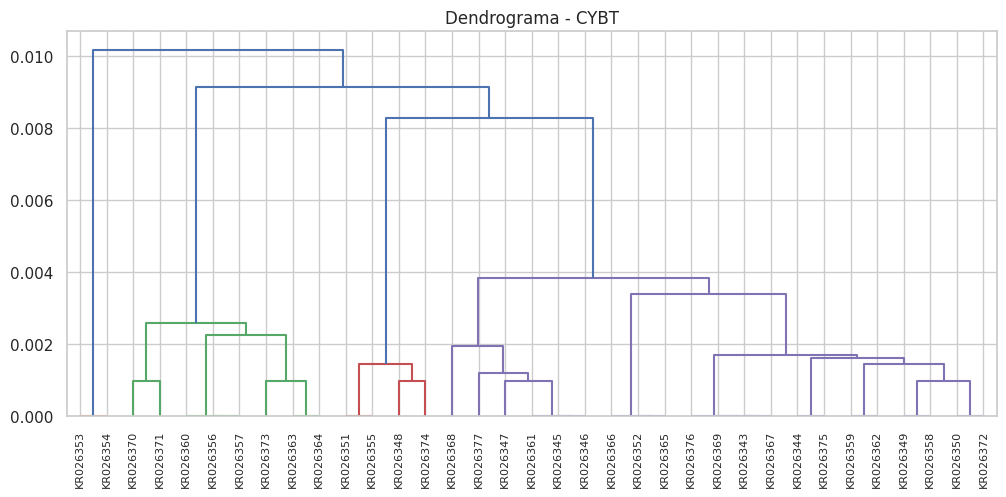

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

dendrogram(
    Z_cybt,
    labels=cybt_id.values,
    leaf_rotation=90
)

ax.set_title('Dendrograma - CYBT')

plt.savefig(results_bootstrap_dir / "dendrogram_cybt.png")
plt.show()

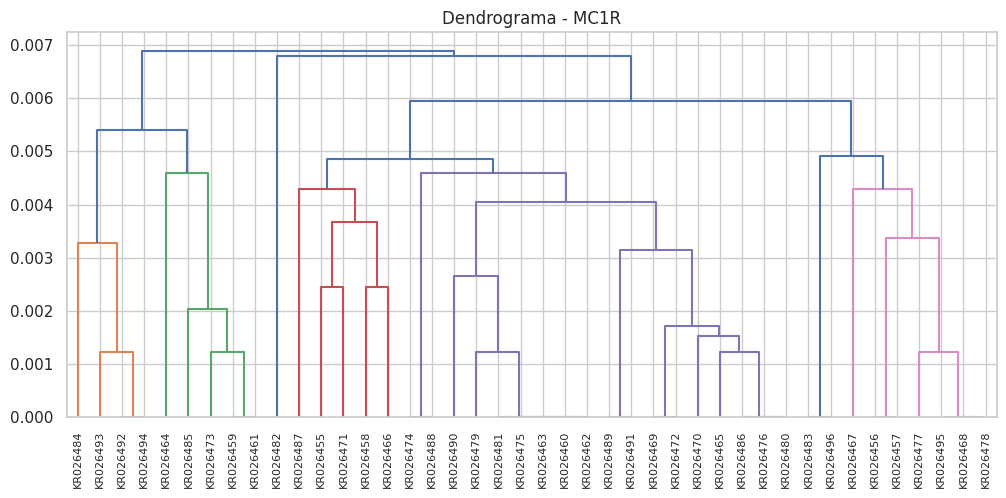

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

dendrogram(
    Z_mc1r,
    labels=mc1r_id.values,
    leaf_rotation=90
)

ax.set_title('Dendrograma - MC1R')

plt.savefig(results_bootstrap_dir / "dendrogram_mc1r.png")
plt.show()

---

## Bootstrap

A continuación evaluamos la estabilidad de los agrupamientos genéticos mediante bootstrap. 

El procedimiento que utilizaremos consiste en: 

1. remuestrear columas de la matriz genética con reemplazo,
2. reconstruir una nueva matriz bootstrap,
3. recalcular distancias genéticas,
4. reconstruir el clustering jerárquico,
5. y medir la estabilidad de los clusters observados.

Con este enfoque evaluamos que tan robusta es la estructura genética ante variaciones en los nucleótidos observados. 

In [21]:
def bootstrap_pos(X):
    """
    Bootstrap sobre columnas (posiciones nucleóticas).
    """
    n_pos = X.shape[1]
    sampled_cols = np.random.choice(
        n_pos, 
        size=n_pos, 
        replace=True,  # muestreo con reemplazo
    )
    X_sampled = X[:, sampled_cols]
    return X_sampled


def run_bootstrap(X, n_bootstraps):
    bootstrap_scores = []
    for _ in tqdm(range(n_bootstraps)):

        # bootstrap de posiciones nucleóticas
        X_boot = bootstrap_pos(X)

        # distancia genética
        D_boot = pairwise_distances(
            X_boot, 
            metric='hamming'
        )

        # clustering
        Z_boot = linkage(
            squareform(D_boot), 
            method='average'
        )

        # clusters
        labels = fcluster(
            Z_boot, 
            t=2, 
            criterion='maxclust'
        )

        # silhouette score
        score = silhouette_score(
            D_boot, 
            labels, 
            metric='precomputed'
        )

        bootstrap_scores.append(score)
    
    return bootstrap_scores

In [22]:
# bootstrap config
N_BOOTSTRAPS = 1000
n_samples_cybt, n_pos_cybt = X_cybt.shape  # muestras, posiciones
n_samples_mc1r, n_pos_mc1r = X_mc1r.shape  # muestras, posiciones

In [23]:
# scores cybt
bootstrap_scores_cybt = run_bootstrap(X_cybt, n_bootstraps=N_BOOTSTRAPS)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 406.74it/s]


In [24]:
print(bootstrap_scores_cybt[:5])
print(len(bootstrap_scores_cybt))

[0.4909018486704597, 0.4163698875529233, 0.5625627717168913, 0.5533202836677266, 0.5746685964595628]
1000


In [25]:
pd.DataFrame(bootstrap_scores_cybt).describe()

,0
count,1000.000000
mean,0.587595
std,0.079130
min,0.352606
25%,0.538641
50%,0.589351
75%,0.642564
max,0.808877


In [26]:
np.quantile(bootstrap_scores_cybt, [0.025, 0.975])

array([0.42007387, 0.74067553])

In [27]:
# scores mc1r
bootstrap_scores_mc1r = run_bootstrap(X_mc1r, n_bootstraps=N_BOOTSTRAPS)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 392.60it/s]


In [28]:
print(bootstrap_scores_mc1r[:5])
print(len(bootstrap_scores_mc1r))

[0.5681323286490972, 0.3244191177670106, 0.4348758492883693, 0.47146926029144953, 0.4535901961794816]
1000


In [29]:
pd.DataFrame(bootstrap_scores_mc1r).describe()

,0
count,1000.000000
mean,0.491953
std,0.100568
min,0.238286
25%,0.421716
50%,0.489493
75%,0.558747
max,0.847171


In [30]:
np.quantile(bootstrap_scores_mc1r, [0.025, 0.975])

array([0.31222111, 0.70044481])

Graficamos resultados:

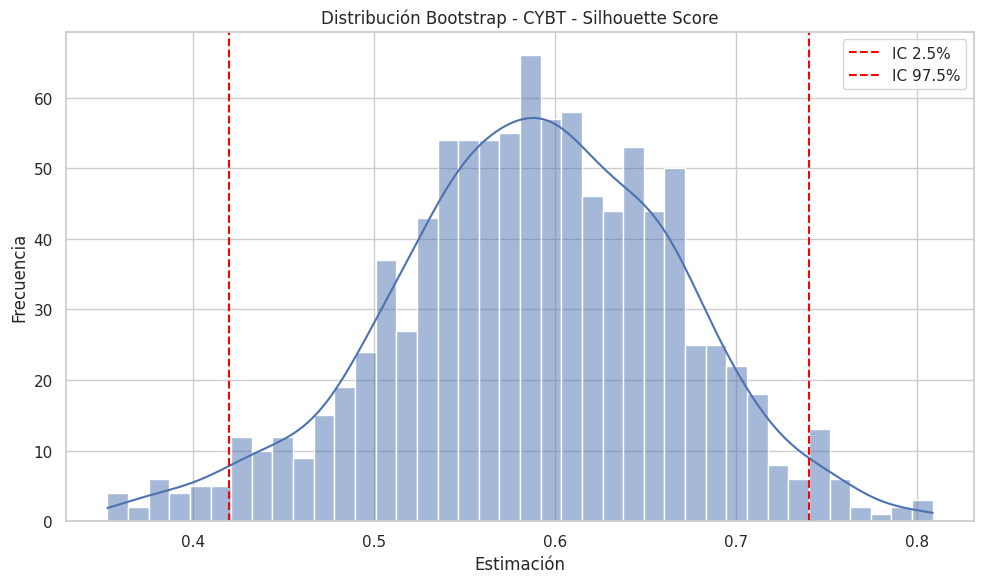

In [31]:
ci_low = np.percentile(bootstrap_scores_cybt, 2.5)
ci_high = np.percentile(bootstrap_scores_cybt, 97.5)

fig, ax = plt.subplots()

# ax.hist(bootstrap_scores_cybt, bins=40)
sns.histplot(
    bootstrap_scores_cybt,
    kde=True,
    ax=ax, 
    bins=40
)
ax.axvline(ci_low, linestyle='--',color='red', label='IC 2.5%')
ax.axvline(ci_high, linestyle='--', color='red', label='IC 97.5%')
# ax.axvline(score_cybt, linestyle='-',color='green', label='Score original')

ax.set_title('Distribución Bootstrap - CYBT - Silhouette Score')
ax.set_xlabel('Estimación')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.savefig(results_bootstrap_dir / "bootstrap_distribution_cybt.png")
plt.show()

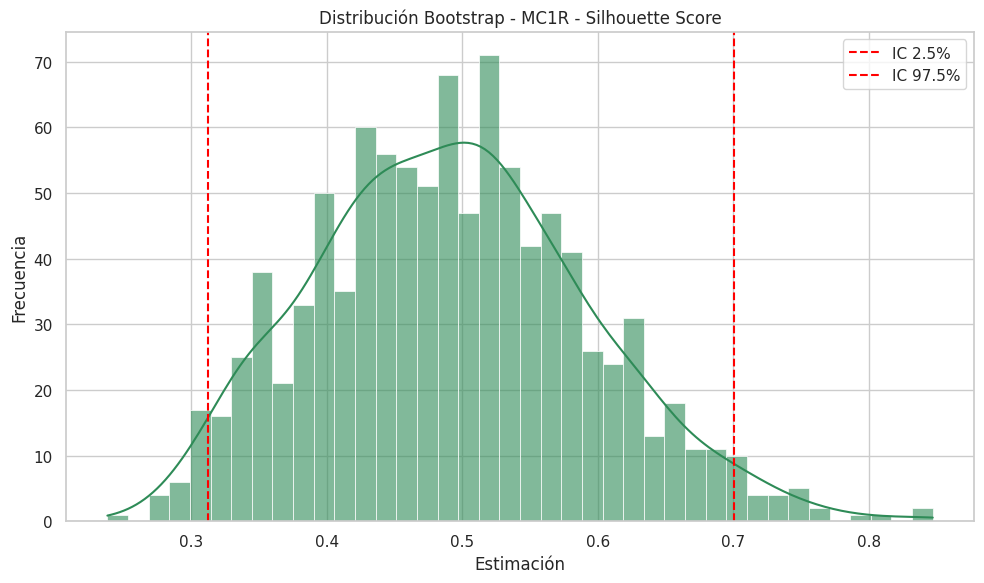

In [32]:
ci_low = np.percentile(bootstrap_scores_mc1r, 2.5)
ci_high = np.percentile(bootstrap_scores_mc1r, 97.5)

fig, ax = plt.subplots()

# ax.hist(bootstrap_scores_mc1r, bins=40)
sns.histplot(
    bootstrap_scores_mc1r,
    bins=40,
    kde=True,
    color="seagreen",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

ax.axvline(ci_low, linestyle='--',color='red', label='IC 2.5%')
ax.axvline(ci_high, linestyle='--', color='red', label='IC 97.5%')
# ax.axvline(score_mc1r, linestyle='-',color='green', label='Score original')

ax.set_title('Distribución Bootstrap - MC1R - Silhouette Score')
ax.set_xlabel('Estimación')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.savefig(results_bootstrap_dir / "bootstrap_distribution_mc1r.png")
plt.show()

---

## Resultados

La información genética fue evaluada usando: 

* reducción de dimensionalidad con PCA,
* clustering jerárquico,
* y bootstrap sobre posiciones de nucleótidos.

Los análisis se realizaron de manera indipendiente en ambos marcadores. 

El objetivo fue evaluar si la estructura observada consiste con la hipótesis de múltiples grupos genéticamente diferenciados.

---

### PCA

Utilizando PCA se proyectó la información genética en un espacio bidimensional. 

<img src="../results/bootstrap/pca_cybt.png" width="45%"> <img src="../results/bootstrap/pca_mc1r.png" width="45%">

El PCA del marcador `cybt` mostró que la población está dividida en varios grupos.

En la gráfica se pueden ver:

* varios grupos de individuos muy juntos entre sí,
* separación clara entre algunos grupos,
* y poca mezcla entre varios conjuntos de individuos.

En particular, se observa:

* dos grupos principales bien diferenciados,
* un grupo pequeño separado del resto,
* y un individuo aislado de los demás.

Estos patrones sugieren que existe variación genética dentro de la población analizada.

El PCA del marcador `mc1r` mostró una estructura más continua y menos dividida que la observada en `cybt`.

Los individuos se distribuyen principalmente en dos diagonales, con una dispersión moderada, formando dos regiones principales separadas.

A diferencia de `cybt`:

* los grupos se mezclan más entre sí,
* la separación entre grupos es menos clara,
* y la estructura parece más gradual que completamente separada.

Aun así, se pueden identificar dos grupos principales. 

---

## Clustering

<img src="../results/bootstrap/dendrogram_cybt.png" width="45%"> <img src="../results/bootstrap/dendrogram_mc1r.png" width="45%">

El dendrograma del marcador `cybt` mostró una estructura jerárquica clara.

Se observaron:

* tres grupos principales,
* poca distancia entre individuos del mismo grupo,
* y mayor separación entre los distintos grupos.

Además:

* los grupos son compactos internamente,
* y los grupos principales se unen hasta altas distancias en el dendrograma.

En particular, los grupos principales permanecen separados hasta distancias altas, lo que indica una diferenciación consistente entre ellos.

La presencia de ramas compactas y separadas sugiere la existencia de varios grupos genéticos diferenciados.

El dendrograma del marcador `mc1r` mostró una estructura más dispersa y menos separada que la observada en `cybt`.

Se observaron:

* varios grupos pequeños,
* distancias de unión relativamente cercanas,
* y una estructura jerárquica más gradual.

Aunque se pueden distinguir algunos subconjuntos:

* la separación entre grupos es menor,
* y la estructura general parece menos fragmentada.

Esto sugiere que el marcador `mc1r` presenta cierta estructura jerárquica, aunque menos marcada que la observada en cybt.


---

### PCA + Clustering

Podemos unir la información obtenida en los análisis de PCA y clustering. 

El dendrograma del marcador `cybt` muestra 3 grupos principales. Podemos obtener las etiquetas de los individuos en los grupos y complementar el scatter plot de PCA. 

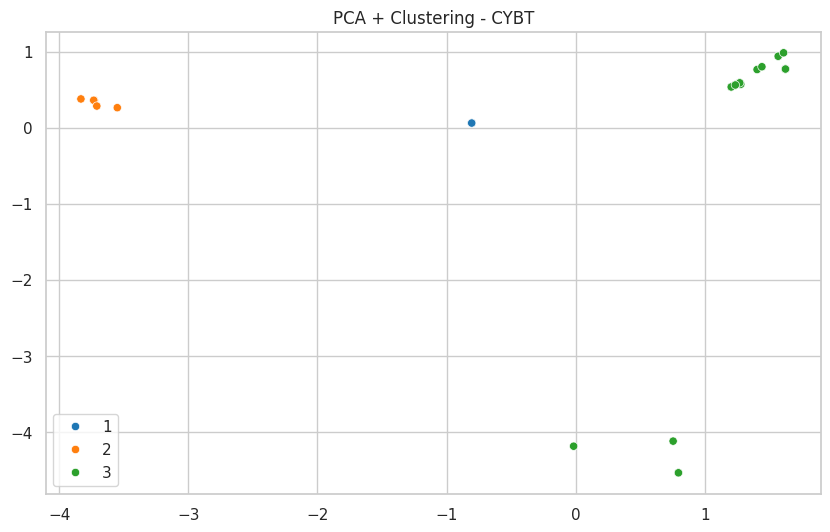

In [33]:
labels_cybt = fcluster(
    Z_cybt, 
    t=3, 
    criterion='maxclust'
)

sns.scatterplot(
    x=X_pca_cybt[:, 0],
    y=X_pca_cybt[:, 1],
    hue=labels_cybt,
    palette='tab10'
)
plt.title('PCA + Clustering - CYBT')
plt.savefig(results_bootstrap_dir / "pca_clust_cybt.png")
plt.show()

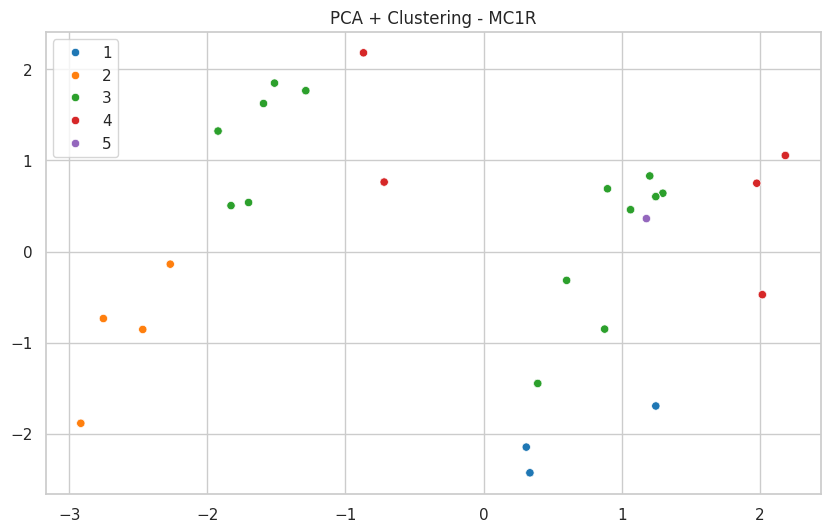

In [34]:
labels_mc1r = fcluster(
    Z_mc1r, 
    t=5, 
    criterion='maxclust'
)

sns.scatterplot(
    x=X_pca_mc1r[:, 0],
    y=X_pca_mc1r[:, 1],
    hue=labels_mc1r,
    palette='tab10'
)

plt.title('PCA + Clustering - MC1R')
plt.savefig(results_bootstrap_dir / "pca_clust_mc1r.png")
plt.show()

In [35]:
html_content = """
<div style="display:flex; flex-direction:column; gap:30px;">

  <div style="display:flex; align-items:center; gap:20px;">
    <img src="../results/bootstrap/pca_clust_cybt.png"
         style="width:40%; object-fit:contain;">

    <img src="../results/bootstrap/dendrogram_cybt.png"
         style="width:55%; object-fit:contain;">
  </div>

  <div style="display:flex; align-items:center; gap:20px;">
    <img src="../results/bootstrap/pca_clust_mc1r.png"
         style="width:40%; object-fit:contain;">

    <img src="../results/bootstrap/dendrogram_mc1r.png"
         style="width:55%; object-fit:contain;">
  </div>

</div>
"""

display(HTML(html_content))

In [36]:
with open("../results/bootstrap/pca_clust.html", "w") as f:
    f.write(html_content)

---

### Bootstrap

La estabilidad de la estructura genética fue evaluada mediante bootstrap de las posiciones de nucleotidos. 

En cada muestreo bootstrap: 

1. se remuestrearon cadenas de nucleótidos con reemplazo,
2. se recalcularon distancias genéticas,
3. se construyo el clustering jerárquico,
4. y se recalculó el silhouette score correspondiente.
 

El silhouette score se utilizó como medida de estabilidad de los clusters: 

$$
s(i) = \frac{b(i)-a(i)}{\max(a(i), b(i))}
$$

Valores cercanos a : 

* 1 indican clusters bien separados,
* 0 indican solapamiento,
* y valores negativos indican mala asignación. 

<img src="../results/bootstrap/bootstrap_distribution_cybt.png" width="45%"> <img src="../results/bootstrap/bootstrap_distribution_mc1r.png" width="45%">

El marcador `cybt` presentó los resultados bootstrap consistentes.

Resumen:

* silhouette promedio $\approx$ 0.58
* desviación estándar $\approx$ 0.08
* IC 95\% $\approx$ [0.43, 0.73]

La distribución bootstrap mostró:

* concentración moderada de valores positivos,
* baja dispersión,
* y ausencia de valores cercanos a cero.

Estos resultados sugieren:

* una estructura de agrupamiento relativamente estable,
* separación moderada a fuerte entre grupos,
* y buena estabilidad frente al remuestreo de nucleotidos.

En términos prácticos, la estructura observada en cybt se mantiene incluso cuando se realizan perturbaciones bootstrap sobre los sitios genéticos analizados.


El marcador `mc1r` mostró una mayor variabilidad en el análisis bootstrap.

Resumen:

* silhouette promedio $\approx$ 0.49
* desviación estándar $\approx$ 0.10
* IC 95\% $\approx$ [0.31, 0.69]

En comparación con `cybt`:

* los valores presentan mayor dispersión,
* el promedio es menor,
* y los resultados son más sensibles al remuestreo.

Aunque los resultados siguen sugiriendo cierta estructura jerárquica:
* la evidencia es menos estable,
* y la separación entre grupos parece más débil.


---

## Conclusiones

El análisis realizadp permitió evaluar la estructura genética poblacional de *Callisaurus draconoides* utilizando técnicas de reducción de dimensionalidad, clustering jerárquico y validación mediante bootstrap sobre posiciones de nucleótidos.

Los resultados muestran evidencia de agrupamiento y cierta separación entre individuos, especialmente en el marcador `cybt`. En este caso:

* el PCA mostro grupos relativamente diferenciados,
* el drendrograma presentó clusters definidos,
* y el análisis bootstrap indicó una estabilidad moderada de la estructura jerárquica.

Los valores promedio de silhouette score obtenidos fueron:

* `cybt` media $\approx$ 0.58, desviación estándar $\approx$ 0.08
* `mc1r` media $\approx$ 0.49, desviación estándar $\approx$ 0.10

Estos resultados sugieren que los agrupamientos encontrados tienen una separación moderada y se mantienen relativamente estables bajo remuestreo de nucleótidos.

Además, la distribución bootstrap de `cybt` presentó:

* menor dispersión,
* valores promedio más altos,
* y un intervalo de confianza más concentrado,

lo que sugiere una estructura genética más estable en comparación con `mc1r`.

Con respecto a las hipótesis planteadas:

$$
H_0: ~\text{Todos los individuos pertenecen a una misma subespecie}
$$

$$
H_1: ~\text{Existen almenos dos grupos genéticamente diferenciados}
$$

Los resultados no apoyan completamente la hipótesis nula. Por el contrario, los análisis muestran evidencia compatible con la presencia de múltiples grupos genéticamente diferenciados, especialmente en el marcador `cybt`.

Sin embargo, estos resultados deben interpretarse como evidencia exploratoria desde un enfoque estadístico y computacional, y no como una conclusión biológica definitiva.

---

## Referencias

1. "Hamming Codes." En *Handbook of Coding Theory*. [ScienceDirect](https://www.sciencedirect.com/science/chapter/handbook/abs/pii/B9780444518750000063?utm_source=chatgpt.com)
2. "Hamming Distance Explained." *DataCamp*. [DataCamp Tutorial](https://www.datacamp.com/tutorial/hamming-distance?utm_source=chatgpt.com)
3. "Hamming Code." *Wikipedia, The Free Encyclopedia*. [Wikipedia - Hamming Code](https://en.wikipedia.org/wiki/Hamming_code?utm_source=chatgpt.com)
